Saving netflix_titles.csv to netflix_titles (1).csv

--- FIRST 5 ROWS ---
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September

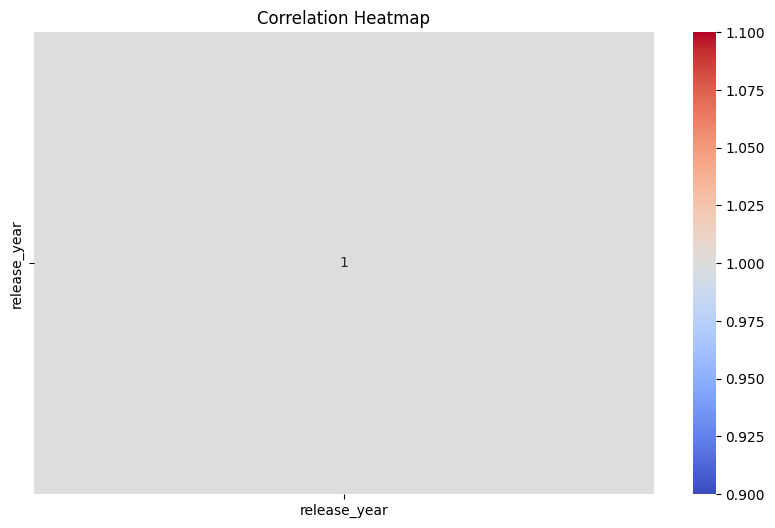

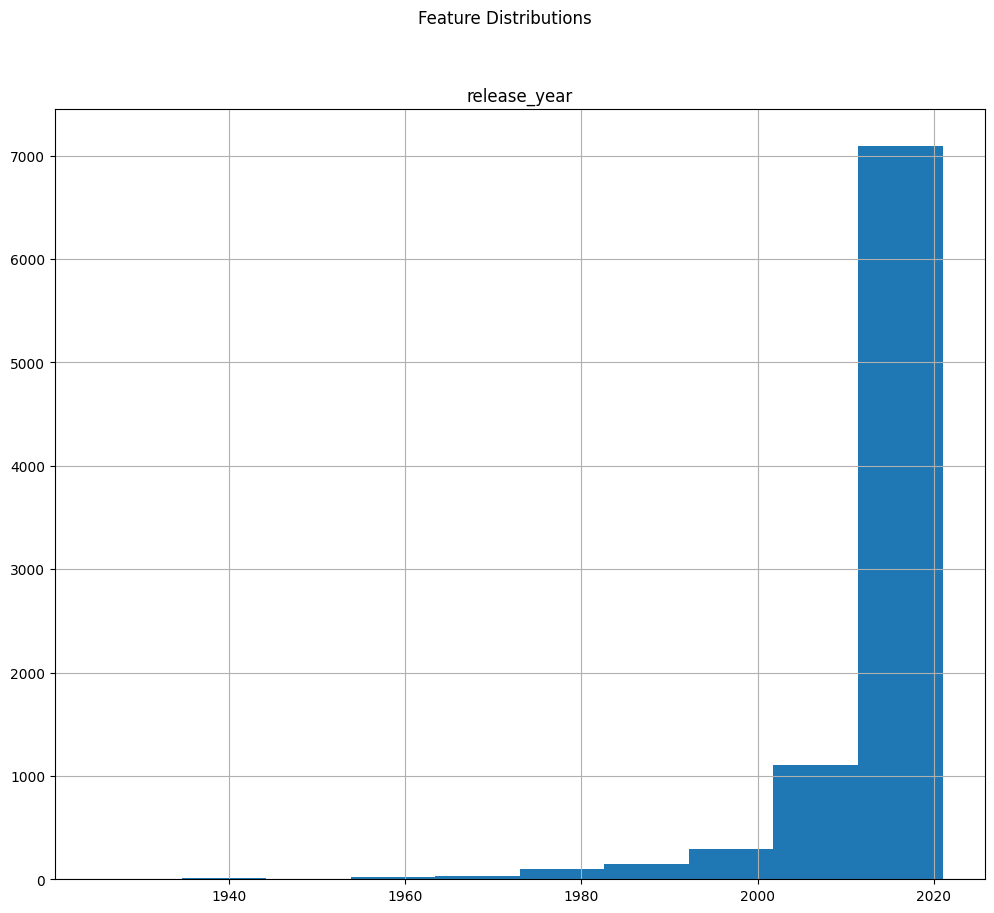

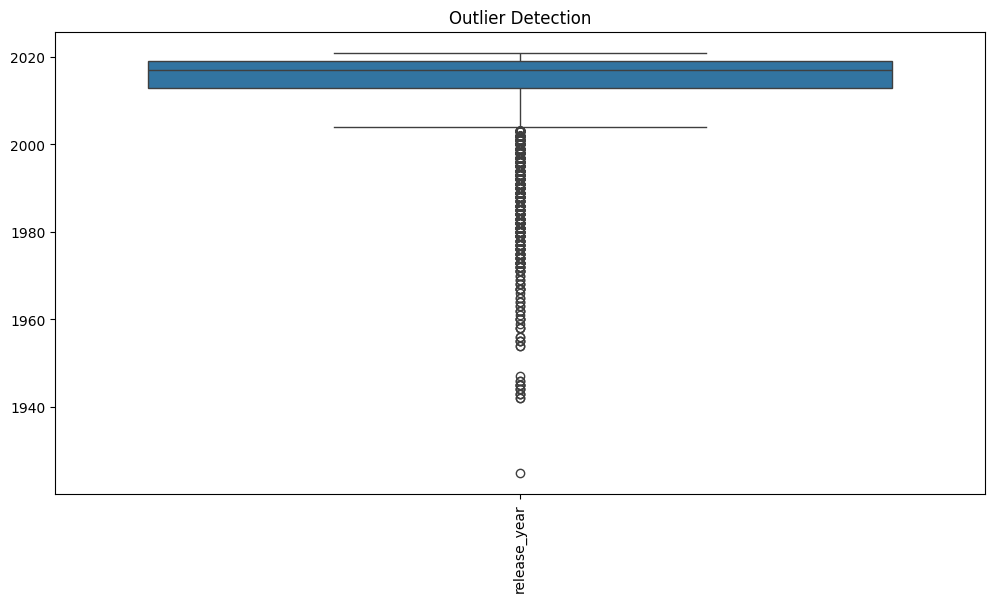

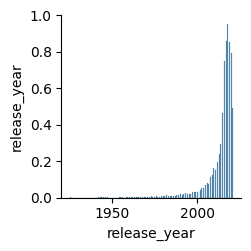


--- VALUE COUNTS: show_id ---
show_id
s8807    1
s1       1
s2       1
s3       1
s4       1
s5       1
s6       1
s8791    1
s8790    1
s8789    1
Name: count, dtype: int64


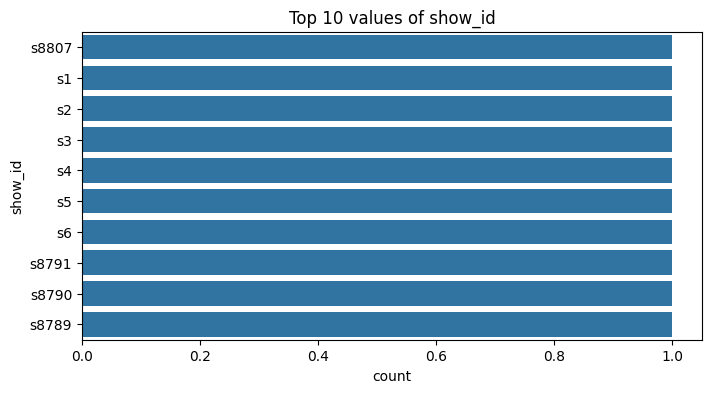


--- VALUE COUNTS: type ---
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


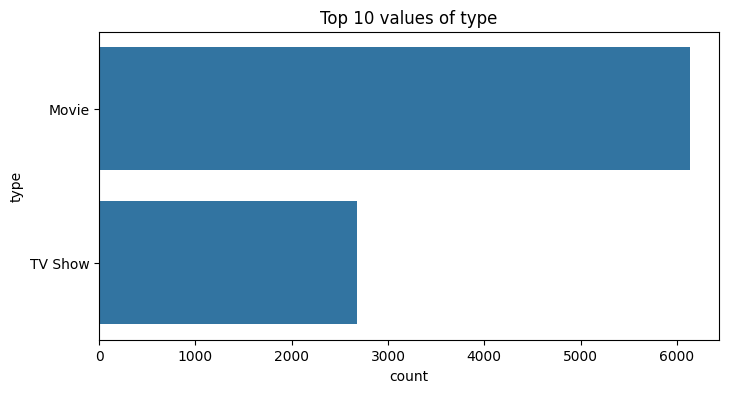


--- VALUE COUNTS: title ---
title
Feb-09                              2
22-Jul                              2
15-Aug                              2
Cooked                              1
Care Bears & Cousins                1
Hannibal Buress: Comedy Camisado    1
Turbo FAST                          1
Masha's Tales                       1
Chelsea Does                        1
Ricardo O'Farrill Abrazo Genial     1
Name: count, dtype: int64


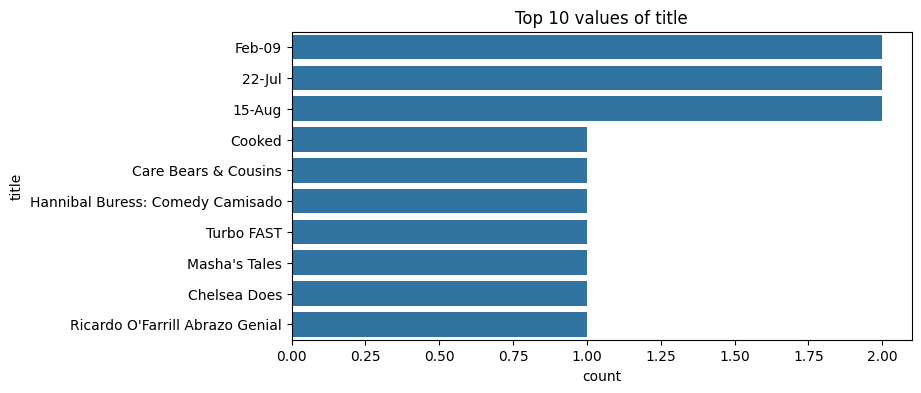


--- VALUE COUNTS: director ---
director
Rajiv Chilaka             2653
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Jay Chapman                 12
Martin Scorsese             12
Steven Spielberg            11
Name: count, dtype: int64


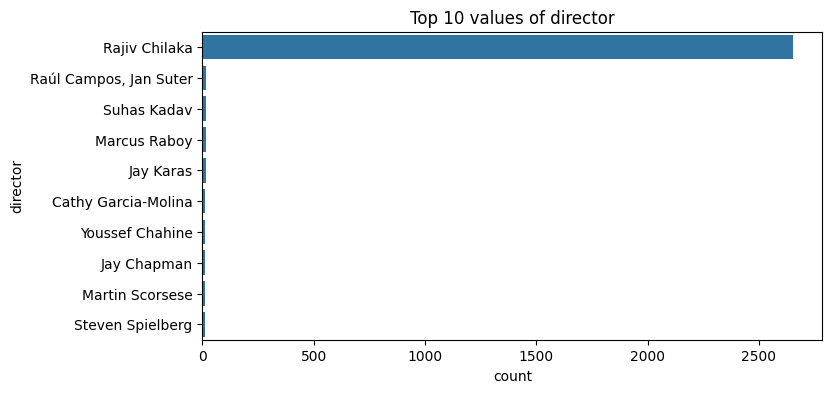


--- VALUE COUNTS: cast ---
cast
David Attenborough                                                                                                        844
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil                                    14
Samuel West                                                                                                                10
Jeff Dunham                                                                                                                 7
Craig Sechler                                                                                                               6
David Spade, London Hughes, Fortune Feimster                                                                                6
Kevin Hart                                                                                                                  6
Michela Luci, Jamie Watson, Eric Peterson, Anna Claire Bartlam, Nicolas Aqui, Cory Do

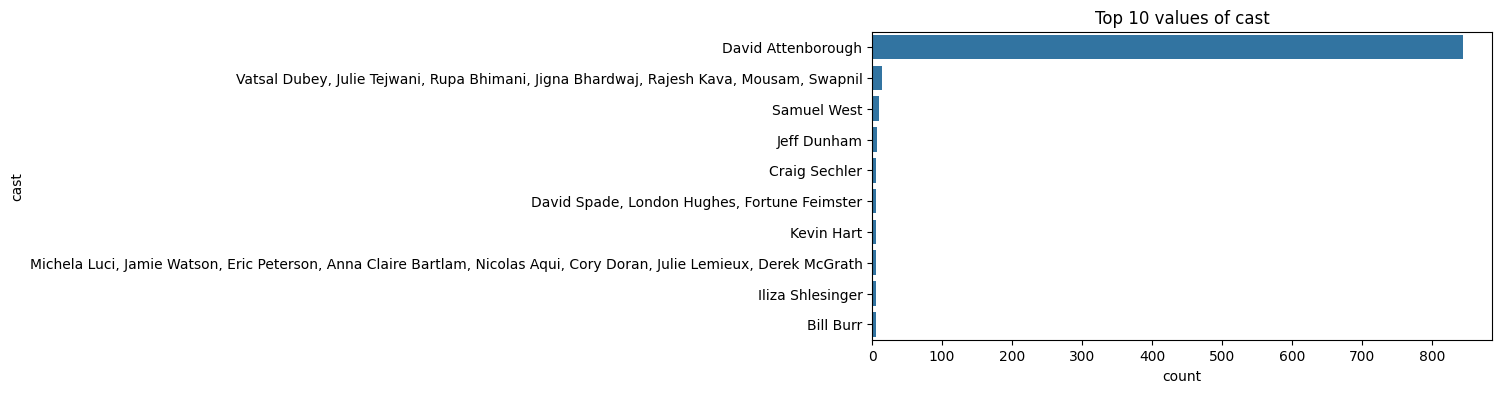


--- VALUE COUNTS: country ---
country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


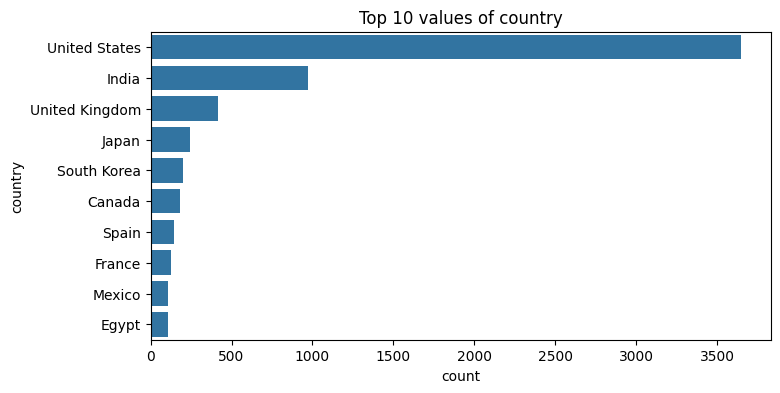


--- VALUE COUNTS: date_added ---
date_added
January 1, 2020      119
November 1, 2019      89
March 1, 2018         75
December 31, 2019     74
October 1, 2018       71
July 1, 2021          60
October 1, 2019       60
November 1, 2018      60
September 1, 2021     56
January 1, 2018       52
Name: count, dtype: int64


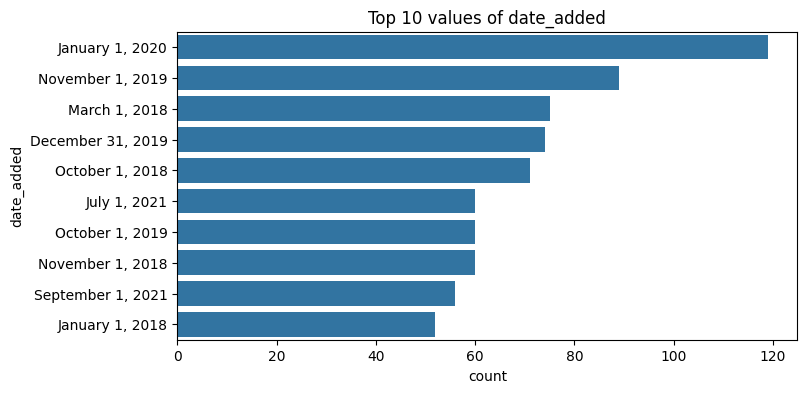


--- VALUE COUNTS: rating ---
rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


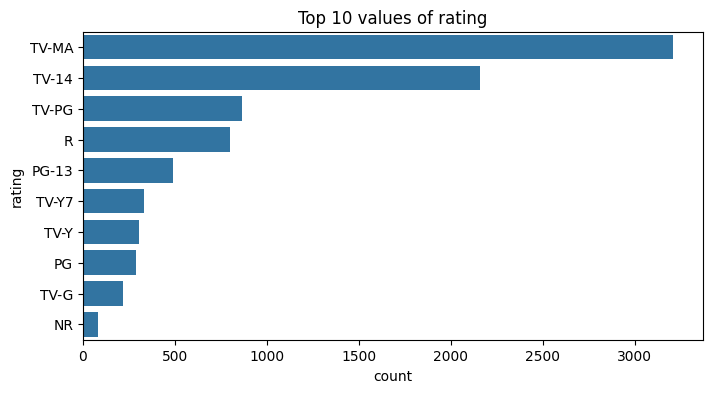


--- VALUE COUNTS: duration ---
duration
1 Season     1796
2 Seasons     425
3 Seasons     199
90 min        152
97 min        146
94 min        146
93 min        146
91 min        144
95 min        137
96 min        130
Name: count, dtype: int64


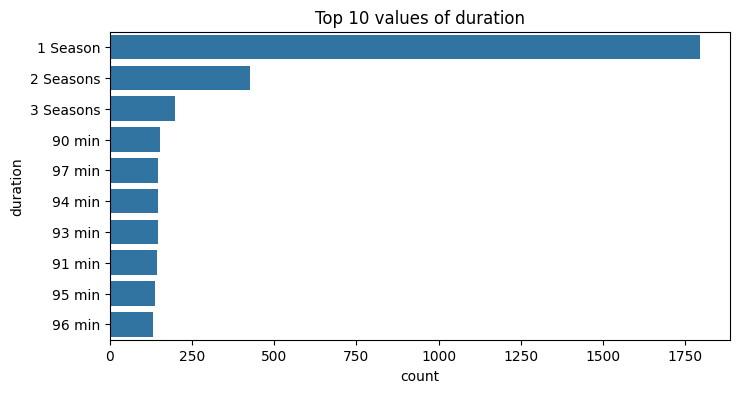


--- VALUE COUNTS: listed_in ---
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


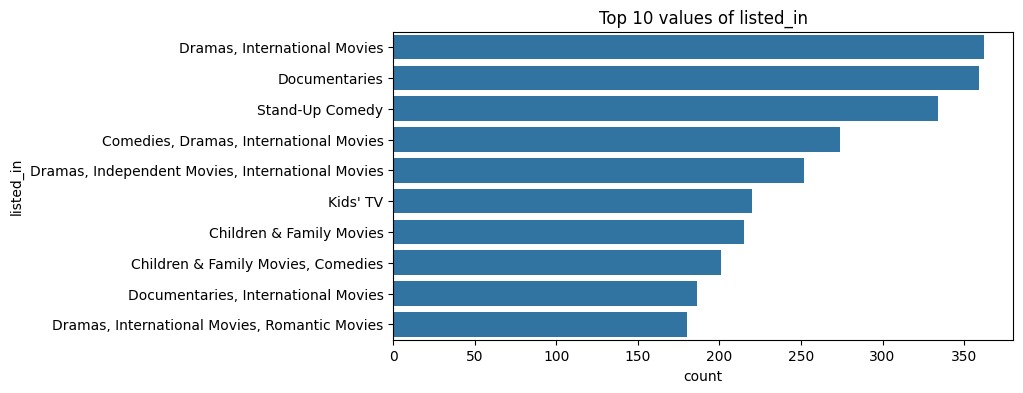


--- VALUE COUNTS: description ---
description
Paranormal activity at a lush, abandoned property alarms a group eager to redevelop the site, but the eerie events may not be as unearthly as they think.    4
A surly septuagenarian gets another chance at her 20s after having her photo snapped at a studio that magically takes 50 years off her life.                 3
Multiple women report their husbands as missing but when it appears they are looking for the same man, a police officer traces their cryptic connection.     3
Challenged to compose 100 songs before he can marry the girl he loves, a tortured but passionate singer-songwriter embarks on a poignant musical journey.    3
A scheming matriarch plots to cut off her disabled stepson and his wife from the family fortune, creating a division within the clan.                        2
As a series of murders hit close to home, a video game designer with post-traumatic stress must confront her demons, or risk becoming their victim.          2

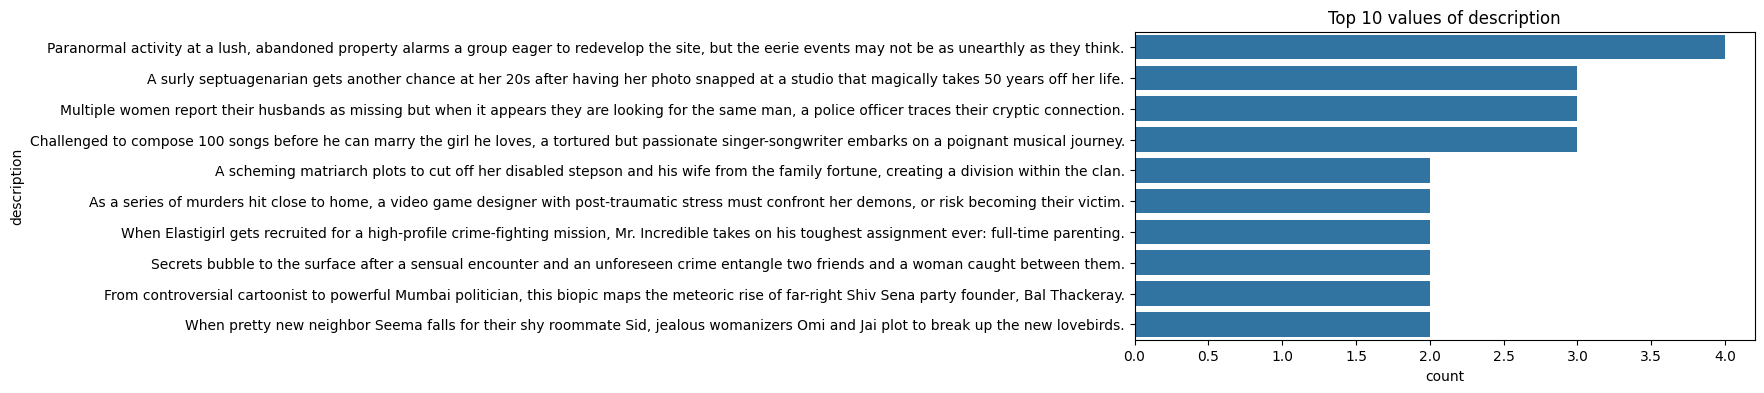


✅ EDA COMPLETE. Cleaned dataset saved as 'cleaned_netflix_titles.csv'


In [ ]:
# ==============================
# 📊 EXPLORATORY DATA ANALYSIS
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 0. UPLOAD FILE (COLAB STEP)
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_csv("netflix_titles.csv")

print("\n--- FIRST 5 ROWS ---")
print(df.head())

# ==============================
# 2. BASIC INFO
# ==============================
print("\n--- SHAPE ---")
print(df.shape)

print("\n--- INFO ---")
print(df.info())

print("\n--- STATISTICS ---")
print(df.describe(include='all'))

# ==============================
# 3. MISSING VALUES CHECK
# ==============================
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# Fill numeric missing values with median
df = df.fillna(df.median(numeric_only=True))

# Fill categorical missing values with mode
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# ==============================
# 4. DUPLICATES
# ==============================
print("\n--- DUPLICATES ---")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ==============================
# 5. COLUMN NAMES
# ==============================
print("\n--- COLUMNS ---")
print(df.columns)

# ==============================
# 6. CORRELATION HEATMAP
# ==============================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 7. HISTOGRAMS
# ==============================
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()

# ==============================
# 8. BOX PLOTS
# ==============================
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

# ==============================
# 9. PAIRPLOT (NUMERIC ONLY)
# ==============================
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

# ==============================
# 10. CATEGORY ANALYSIS
# ==============================
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n--- VALUE COUNTS: {col} ---")
    print(df[col].value_counts().head(10))

    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Top 10 values of {col}")
    plt.show()

# ==============================
# 11. SAVE CLEANED DATA
# ==============================
df.to_csv("cleaned_netflix_titles.csv", index=False)

print("\n✅ EDA COMPLETE. Cleaned dataset saved as 'cleaned_netflix_titles.csv'")